# Lec8 - Decision Trees, Random forest, k-Nearest Neighbors & k-Fold Cross Validation


In [1]:
########################################
# Imports
########################################

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml as get_dataset # downloads datasets from sklearn.datasets (OpenML)
from mpl_toolkits.axes_grid1 import make_axes_locatable # for advanced plot layouts
from scipy import stats # from the scientific computing library import the 'stats' module (Prob distributions, Statistical tests, Descriptive stats..)
from tqdm import tqdm_notebook # just for progress bars (to show the progress of a loop or a long computation)

# MNIST dataset

In this lab we will use the handwritten digits dataset, a collection of $28x28$ grayscale images containing the digits from $0$ to $9$. We will implement **$k$-Nearest Neighbors** (k-NN) for classifing new unseen images of digits. In particular we will see how to implement **$5$-Fold Cross-Validation** for finding the best parameter $k$ of the k-NN algorithm. Let's start!


The first step is to load the dataset, that in this case is already contained in the *sklearn* package. Once loaded we have to implement the **$5$-Fold Cross-Validation**.


In [2]:
########################################
# Dataset
########################################

# Load the dataset
x, y = get_dataset('mnist_784', version=1, return_X_y=True)
x, y = x.to_numpy(), y.to_numpy()

In [3]:
print(x.shape, y.shape)

# X contains all the features of the images
# Y contains the responses (the true value of the digits)

print(x[1].shape) # number of pixels per image
x[1]

(70000, 784) (70000,)
(784,)


array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  51, 159, 253,
       159,  50,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  48, 238,
       252, 252, 252, 237,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

# EX 1 : Complete the code below

***Hint***: to solve the exercise use the functions
* [np.random.shuffle(...)](https://numpy.org/doc/stable/reference/random/generated/numpy.random.shuffle.html)
* [np.ceil(...)](https://numpy.org/doc/stable/reference/generated/numpy.ceil.html)

################################################################################
# SUMMARY
################################################################################

Train set size: 1600
Test set size: 400
Number of pixels per image: 784 = 28x28

################################################################################
# SHOW SAMPLES
################################################################################



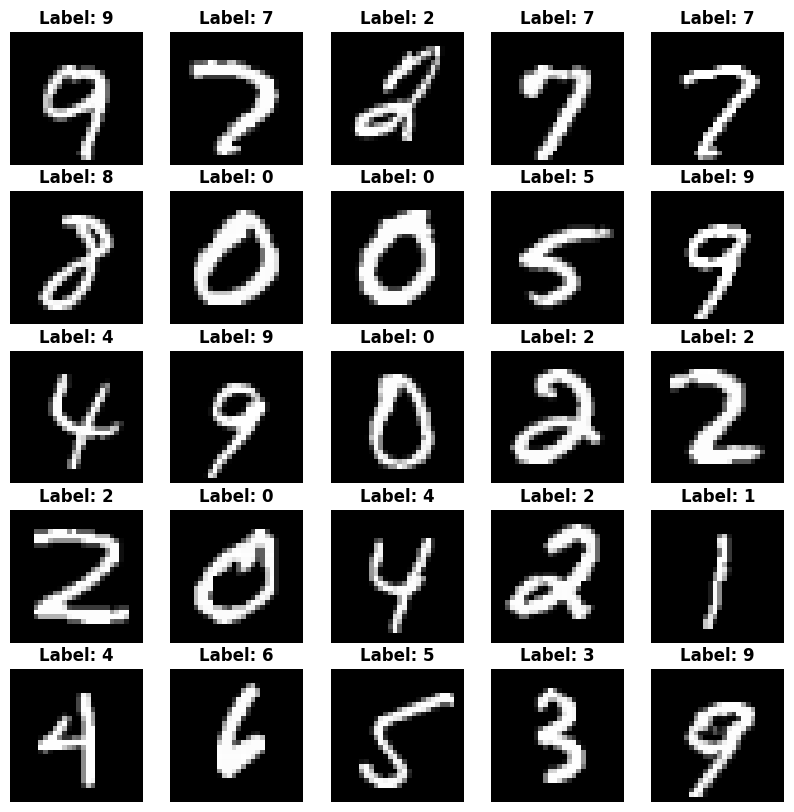

In [4]:
# Function for splitting the dataset
def split_data(x, y, train_ratio=0.8, seed=None):
    idx_samples = np.arange(len(x), dtype=np.int32) # produces a numpy array of values from 0 -> len(x)-1 (in sequenced order)
    if seed is not None:
        np.random.seed(seed)

    ### HERE YOUR CODE ###

    # Shuffle the idx samples
    np.random.shuffle(idx_samples) # performs in-place shuffling (directly applied to idx_samples)
    
    # Split the idx into train and validation idx
    train_size = int(0.8*len(x))
    idx_train = idx_samples[:train_size] # This creates a np array of size 0.8*len(x) containing random indices from idx_samples
    idx_valid = idx_samples[train_size:] # Same but for validation

    "x[idx_train]" # This will use the indices present in idx_train to extract the elements from x at those indices
    
    return x[idx_train], y[idx_train], x[idx_valid], y[idx_valid]



# Let's work with a subset of the dataset, only for reducing time execution
x, y = x[:2000], y[:2000]

# Split data into train and test sets
x_train, y_train, x_test, y_test = split_data(x, y, train_ratio=0.8,
                                                seed=1234)

# Process the dataset
x_train, x_test = x_train / 255, x_test / 255 # converts to range [0, 1]
y_train, y_test = y_train.astype(np.int32), y_test.astype(np.int32)

# Print summary of the dataset
print('################################################################################')
print('# SUMMARY')
print('################################################################################\n')
print('Train set size:', x_train.shape[0])
print('Test set size:', x_test.shape[0])
print('Number of pixels per image:', x_train.shape[1], '= 28x28')
print()

# Plot some samples of the dataset
print('################################################################################')
print('# SHOW SAMPLES')
print('################################################################################\n')
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.title(f'Label: {y_train[i]}', fontweight='bold')
    plt.imshow(x_train[i].reshape(-1, 28), cmap='gray')
    plt.axis('off')
plt.show()

# k-Fold Cross Validation

Here you can see a simple diagram to summarize the overall procedure:

![alt text](https://i.postimg.cc/8CVKFb35/k-fold.png)


# EX 2: Complete the following code to implement *k_fold_cv*  function.


***Hint***: to solve the exercise use the functions
* [np.random.shuffle(...)](https://numpy.org/doc/stable/reference/random/generated/numpy.random.shuffle.html)
* [np.split(...)](https://numpy.org/doc/stable/reference/generated/numpy.split.html)
* [np.concatenate(...)](https://numpy.org/doc/stable/reference/generated/numpy.concatenate.html)

In [73]:
########################################
# k-Fold Cross Validation
########################################

def k_fold_cv(x, y, k=5, seed=None):
    '''
    input x: input samples ndarray of shape (num_samples, feat_dim)
    input y: labels ndarray of shape (num_samples)
    input k: number of folds
    input seed: seed for random shuffle
    '''
    idx_samples = np.arange(len(x), dtype=np.int32)
    if seed is not None:
        np.random.seed(seed)
    
    ### HERE YOUR CODE ###

    # Shuffle the samples indices
    np.random.shuffle(idx_samples)
    # Split the idx samples into k-folds
    idx_sample_folds = np.array_split(idx_samples, k) # this splits the data cleanly into roughly equally sized folds
    ### END CODE ###

    x_train_folds, y_train_folds = [], []
    x_valid_folds, y_valid_folds = [], []
    for idx_k in range(k): # This loop is to extract the test fold (repeated k times)
        idx_train, idx_valid = [], []
        for idx_fold in range(k): # This loop classifies each fold as either training or testing
            fold = idx_sample_folds[idx_fold]
            
            if idx_k == idx_fold:
                idx_valid += list(fold) # [fold] was creating a list inside idx_valid list, making complications when extracting the idx from X.
                                                                # list(fold) works normally; it adds the elements of folds into idx_valid (list concat)
            else:
                idx_train += list(fold) # same here

    ### HERE YOUR CODE ###
        # Concatenate folds

        x_train_folds.append(x[idx_train]) # += was giving me an error of different shapes. append() works; it creates a list of numpy arrays
        y_train_folds.append(y[idx_train])
        x_valid_folds.append(x[idx_valid])
        y_valid_folds.append(y[idx_valid])

    ### END CODE ###

    return x_train_folds, y_train_folds, x_valid_folds, y_valid_folds

# Split train set into k folds, k-1 for train and 1 for validation
x_train_folds, y_train_folds, x_valid_folds, y_valid_folds = k_fold_cv(x_train, y_train, k=5, seed=1234)

In [74]:
# Summary of the k-Fold Cross Validation
print('################################################################################')
print('# SUMMARY k-FOLD CROSS VALIDATION')
print('################################################################################\n')
print('k :', len(x_train_folds))
print('Train size (= (k-1) * fold_size):', len(x_train_folds[0]))
print('Validatio size (= fold size):', len(x_valid_folds[0]))


################################################################################
# SUMMARY k-FOLD CROSS VALIDATION
################################################################################

k : 5
Train size (= (k-1) * fold_size): 1280
Validatio size (= fold size): 320


# k-Nearest Neighbors
Given a training data

$$\mathcal{T} = \{ (x_1, y_1), \dots, (x_N, y_N) \}$$

the algorithm makes predictions as follows:

> * **Input**: training data $\mathcal{T}$, $1 \leq k \in \mathbb{N}$ and a new data point $x$
* **Output**: predict class for $x$
 * $\mathcal{D} \leftarrow \{ x_1, \dots, x_N \}$
 * $\mathcal{N(x)} \leftarrow $ $k$ closest points to $x$ in $\mathcal{D}$, under a distance funcion $d(\cdot, \cdot)$
 * return the most frequent class associated with points in $\mathcal{N}(x)$



## Distances
In order to implement $k$-NN we have to specify a distance function. Here the most commons ones:

* **L2 distance**
$$dist_{L2}\left( x^{(0)}, x^{(1)} \right) = \sqrt{\sum_i \left(x^{(0)}_i - x^{(1)}_i\right) ^ 2}$$

* **L1 distance**
$$dist_{L1}\left( x^{(0)}, x^{(1)} \right) = \sum_i \left|x^{(0)}_i - x^{(1)}_i \right|$$

# EX 3: Complete the following code to implement *dist_l2* and *dist_l1*  functions based on the expression above.

In [107]:
########################################
# Distance functions
########################################

# L2 distance
def dist_l2(x_i, x):
    '''
    input x_i: input sample ndarray of shape (feat_dim,)
    input x: input samples ndarray of shape (num_samples, feat_dim)
    output d_i: L2 distance between xi and each sample in x, ndarray of shape (num_samples,)
    '''
    ### HERE YOUR CODE ###
    d_i = np.sqrt(np.sum((x_i - x) ** 2, axis=1))
    ### END CODE ###
    return d_i

# L1 distance
def dist_l1(x_i, x):
    '''
    input x_i: input sample ndarray of shape (feat_dim,)
    input x: input samples ndarray of shape (num_samples, feat_dim)
    output d_i: L1 distance between xi and each sample in x, ndarray of shape (num_samples,)
    '''
    ### HERE YOUR CODE ###
    d_i =np.sum(abs(x_i-x))
    ### END CODE ###
    return d_i


l1 = np.array([2,3,4]) # shape: (3,) target point (coordinates in 3D space)
l2 = np.array([[6,7,8],[1,1,1]]) # shape: (2,3)  neighboring points (also in 3D space) ==> We find the distance btwn l1 point and each point from l2
dist_l2(l1,l2)

array([6.92820323, 3.74165739])

# EX 4: Complete the following code to implement the code below.

***Hint***: to solve the exercise use the functions
* [np.argsort(...)](https://docs.scipy.org/doc/numpy/reference/generated/numpy.argsort.html)
* [stats.mode(...)](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mode.html)

In [123]:
########################################
# K-NN Model class
########################################

class KNNModel(object):
    def __init__(self, x, y, k=1, num_classes=10):
        self.k = k
        self.x = x # x_train
        self.y = y # y_train
        self.num_classes = num_classes # the categories for classification

    def predict(self, x, dist_func, get_freq=False):

        def get_k_closest_points(x_i, x_list):
            '''
            we measure the distance between x_i (a single point in n-dimensional space and all the other points from the training set 'x_list'.
            input x_i: input sample ndarray of shape (feat_dim,)
            input x_list: input samples ndarray of shape (num_samples, feat_dim)
            output idx_k: indices of the kNN, ndarray of shape (k,)
            '''
            ### HERE YOU CODE ###
            d_list = dist_l2(x_i, x_list)
            closest = np.argsort(d_list) # sort the indices of the values, not the values themselves since that would lose the index info of each x
            idx_k = closest[:self.k]
            ### END CODE ###

            return idx_k

        # Compute the distance between x and self.x using dist_func
        dist_matrix_k = np.zeros([x.shape[0], self.k], dtype=np.int32)
        for i, x_i in enumerate(x): # go over the elements in the passed parameter x (which is x_valid in our case)
            dist_matrix_k[i, :] = get_k_closest_points(x_i, self.x)

        # Voting
        y_pred_k = self.y[dist_matrix_k] # Replaces each index in dist_matrix with its label that is present at that index in y. Shape: (N,k)

        # Get the most frequent class
        if get_freq: # if true, also get the voting frequency
            y_pred_freq = np.zeros([len(y_pred_k), self.num_classes], dtype=np.float32)
            for cl in range(self.num_classes): # go over each class/label/digit
                idx = np.where(y_pred_k == cl) # returns the entries at which a match exists (eg: (0,4), (0,5), (3,1) => idx=array([0,0,3] , [4,5,1])
                idx_row = np.array(list(set(idx[0].tolist())), dtype=np.int32) # for each entry in Dim-1, keep only the unique labels ([0,0,3] -> [0,3])
                y_pred_freq[idx_row, cl] = (y_pred_k[idx_row] == cl).sum(axis=-1)
            y_pred_freq = y_pred_freq / self.k
            return y_pred_freq.argmax(axis=-1), y_pred_freq
        else:

            ### HERE YOUR CODE ###
            mode = stats.mode(y_pred_k, axis=1)
            ### END CODE ###

            return mode


t = KNNModel(x_train, y_train, k=3)
f = t.predict(x_valid, x_train)
f.mode

array([7, 7, 3, 2, 8, 4, 9, 8, 6, 7, 3, 7, 7, 5, 1, 6, 4, 7, 0, 4, 1, 9,
       6, 1, 9, 0, 2, 0, 6, 1, 6, 1, 2, 0, 4, 8, 9, 1, 2, 1, 1, 3, 1, 1,
       7, 4, 7, 6, 7, 1, 1, 6, 6, 7, 4, 8, 4, 6, 8, 1, 1, 2, 6, 3, 5, 0,
       3, 9, 3, 2, 4, 9, 0, 2, 2, 1, 5, 2, 7, 8, 6, 9, 2, 0, 9, 3, 1, 6,
       5, 7, 7, 2, 3, 1, 0, 6, 6, 1, 7, 2, 7, 0, 3, 9, 6, 6, 2, 9, 0, 9,
       1, 4, 0, 7, 8, 9, 4, 2, 9, 3, 8, 6, 4, 1, 4, 0, 1, 6, 8, 4, 4, 1,
       0, 0, 6, 7, 0, 8, 0, 3, 7, 7, 9, 1, 7, 8, 7, 8, 4, 7, 5, 4, 9, 5,
       0, 3, 9, 5, 7, 4, 7, 6, 4, 6, 4, 6, 1, 4, 6, 5, 3, 5, 5, 5, 7, 6,
       6, 4, 1, 1, 1, 6, 3, 0, 1, 2, 8, 4, 7, 5, 2, 1, 1, 1, 5, 3, 0, 1,
       4, 2, 2, 5, 5, 3, 2, 0, 1, 4, 6, 9, 1, 7, 1, 9, 0, 2, 6, 6, 6, 6,
       0, 1, 5, 8, 9, 1, 7, 3, 4, 2, 6, 7, 2, 5, 1, 7, 6, 8, 3, 4, 6, 3,
       8, 1, 7, 8, 0, 0, 9, 4, 0, 6, 2, 9, 6, 1, 9, 2, 1, 7, 0, 6, 3, 3,
       4, 0, 1, 1, 8, 5, 8, 1, 1, 5, 9, 9, 0, 5, 5, 6, 3, 4, 1, 6, 8, 4,
       6, 7, 2, 9, 7, 1, 3, 4, 9, 6, 7, 9, 1, 8, 7,

# Find the best parameter k for the k-NN using 5-Fold Cross Validation
We are going to select the best parameter $k$ for the $k$-NN as follows:

$$\hat{k} = argmax_k\{ accuracy_k \}$$

where $accuracy_k$ is the validation accuracy given by the k-NN from the 5-Fold Cross Validation.

In [86]:
def get_accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()

# EX 5

Complete the following code to implement the code below.

This cell can take some minutes to run...

In [126]:
k_list = np.arange(1, 11, dtype=np.int32)

# Loop over k values
acc, acc_std = {}, {}
for k in k_list:

    # Loop over 5-Folds
    acc_folds = []
    for x_train, y_train, x_valid, y_valid in tqdm_notebook(zip(x_train_folds,
                                                                y_train_folds,
                                                                x_valid_folds,
                                                                y_valid_folds),
                                                            total=5,
                                                            desc=f'k = {k}'):
        
        # Create the k-nn model
        knn = KNNModel(x_train, y_train, k=k)
        ### HERE YOUR CODE ###
        # Predict (my predictions are obtained using L2 distance)
        y_valid_pred = knn.predict(x_valid,x_train).mode
        ### END CODE ###

        # Evaluate model
        acc_fold = get_accuracy(y_valid, y_valid_pred)
        acc_folds += [acc_fold]

    # Average accuracies over folds
    acc[k] = np.mean(acc_folds)
    acc_std[k] = np.std(acc_folds)


C:\Users\user\AppData\Local\Temp\ipykernel_15540\1514264350.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for x_train, y_train, x_valid, y_valid in tqdm_notebook(zip(x_train_folds,


k = 1:   0%|          | 0/5 [00:00<?, ?it/s]

k = 2:   0%|          | 0/5 [00:00<?, ?it/s]

k = 3:   0%|          | 0/5 [00:00<?, ?it/s]

k = 4:   0%|          | 0/5 [00:00<?, ?it/s]

...

k = 6:   0%|          | 0/5 [00:00<?, ?it/s]

k = 7:   0%|          | 0/5 [00:00<?, ?it/s]

k = 8:   0%|          | 0/5 [00:00<?, ?it/s]

k = 9:   0%|          | 0/5 [00:00<?, ?it/s]

k = 10:   0%|          | 0/5 [00:00<?, ?it/s]

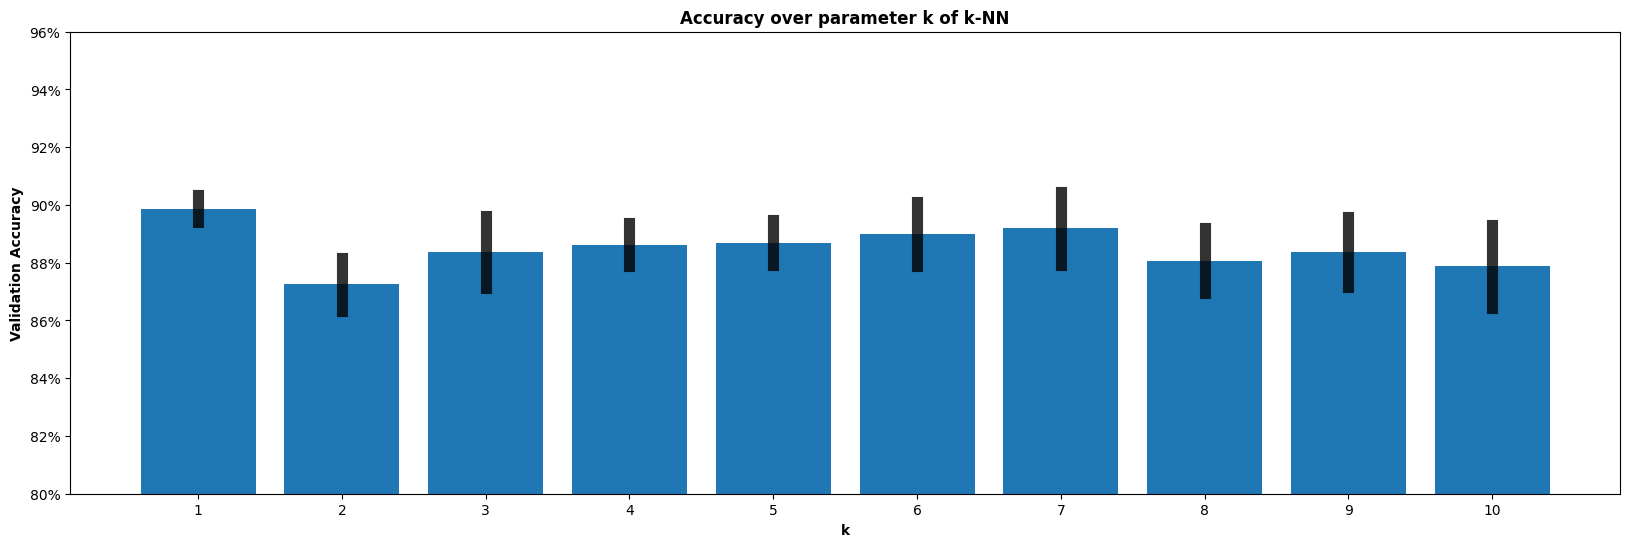

In [127]:
# Plot accuracy over parameter k
plt.figure(figsize=(20, 6))
plt.title('Accuracy over parameter k of k-NN', fontweight='bold')
plt.bar(list(acc.keys()), list(acc.values()))
for k in acc.keys():
    plt.plot([k, k], [acc[k] - acc_std[k], acc[k] + acc_std[k]], c='k', lw=8, alpha=0.8)
plt.ylim(0.8, 0.95)
plt.xlabel('k', fontweight='bold')
plt.ylabel('Validation Accuracy', fontweight='bold')
yticks, _ = plt.yticks()
plt.yticks(yticks, [f'{int(100 * yy)}%' for yy in yticks])
plt.xticks(k_list)
plt.show()

In [128]:
# Best k
idx_k_best = np.array(list(acc.values())).argmax()
k_best = list(acc.keys())[idx_k_best]
print(f'Best k: {k_best}')

# Best model
knn = KNNModel(x_train, y_train, k=k_best)

Best k: 1


In [129]:
# Predictions with best model
pred_valid = knn.predict(x_valid, dist_l2)
pred_test, pred_freq_test = knn.predict(x_test, dist_l2, get_freq=True)

# Evaluation
acc_valid = get_accuracy(y_valid, pred_valid)
acc_test = get_accuracy(y_test, pred_test)
print(f'Validation accuracy: {100 * acc_valid:.2f}%')
print(f'Test accuracy: {100 * acc_test:.2f}%')

Validation accuracy: 50.78%
Test accuracy: 88.25%


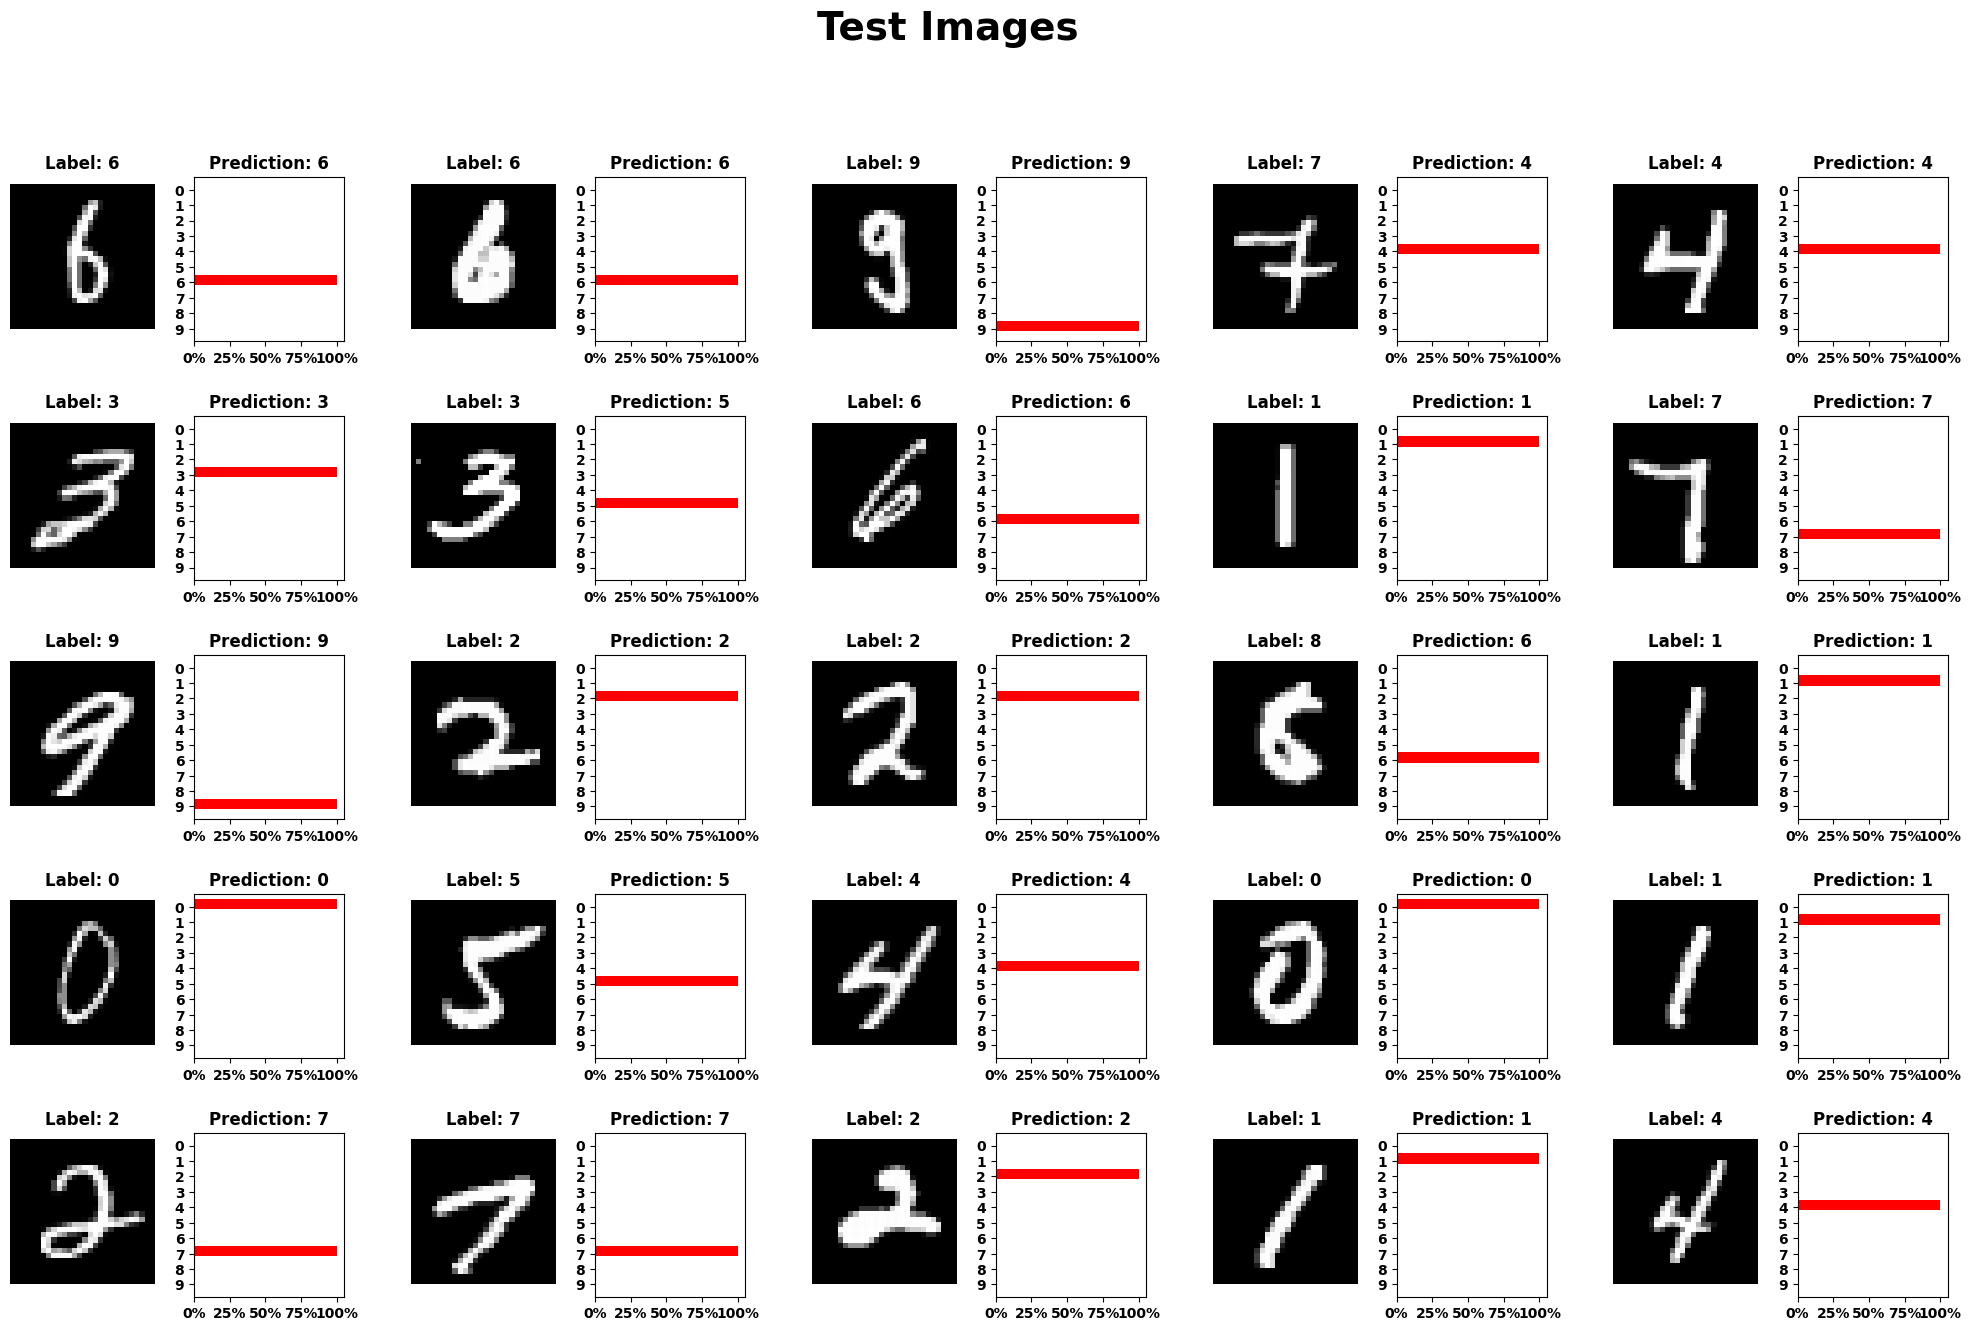

In [130]:
def plot_predictions(x, y, pred_freq, num_col=5, show_max=25, seed=None):
    if len(x) > show_max:
        if seed is not None:
            np.random.seed(seed)
        idx_random = np.random.randint(len(x), size=show_max)
        x = x[idx_random]
        y = y[idx_random]
        pred_freq = pred_freq[idx_random]
    num_rows = int(np.ceil(len(x) / num_col))
    fig, axs = plt.subplots(num_rows, num_col, figsize=(25, num_rows * 3))
    fig.suptitle('Test Images', fontweight='bold', fontsize=28)

    for idx_sample in range(len(x)):
        idx_row = idx_sample // num_col
        idx_col = idx_sample % num_col
        ax = axs[idx_row, idx_col]
        ax.set_title(f'Label: {y[idx_sample]}', fontweight='bold')
        ax.imshow(x[idx_sample].reshape(-1, 28),
                    cmap='gray')
        ax.set_aspect(1.)
        ax.axis('off')
        divider = make_axes_locatable(ax)
        axHisty = divider.append_axes("right", 1.5, pad=0.4, sharey=ax)
        axHisty.barh(np.linspace(0, 27, 10),
                        pred_freq[idx_sample], height=2.0, color='r')
        axHisty.set_xticks(np.linspace(0, 1, 5))
        axHisty.set_title(f'Prediction: {pred_freq[idx_sample].argmax()}',
                          fontweight='bold')
        axHisty.set_xticklabels([f'{int(xx * 100)}%' for xx in np.linspace(0, 1, 5)], fontweight='bold')
        axHisty.set_ylim(30, -2)
        axHisty.set_yticks(np.linspace(0.5, 27.5, 10))
        axHisty.set_yticklabels(np.arange(10), fontweight='bold')
    plt.show()

# Show test results
axs = plot_predictions(x_test, y_test, pred_freq_test, show_max=25, seed=None)

If you change the best parameter $\hat{k}$ for the $k$-NN you can see different behaviour both in terms of accuracy and also in terms of frequency in voting (red lines in the plot above).

Validation accuracy: 48.91%
Test accuracy: 86.00%


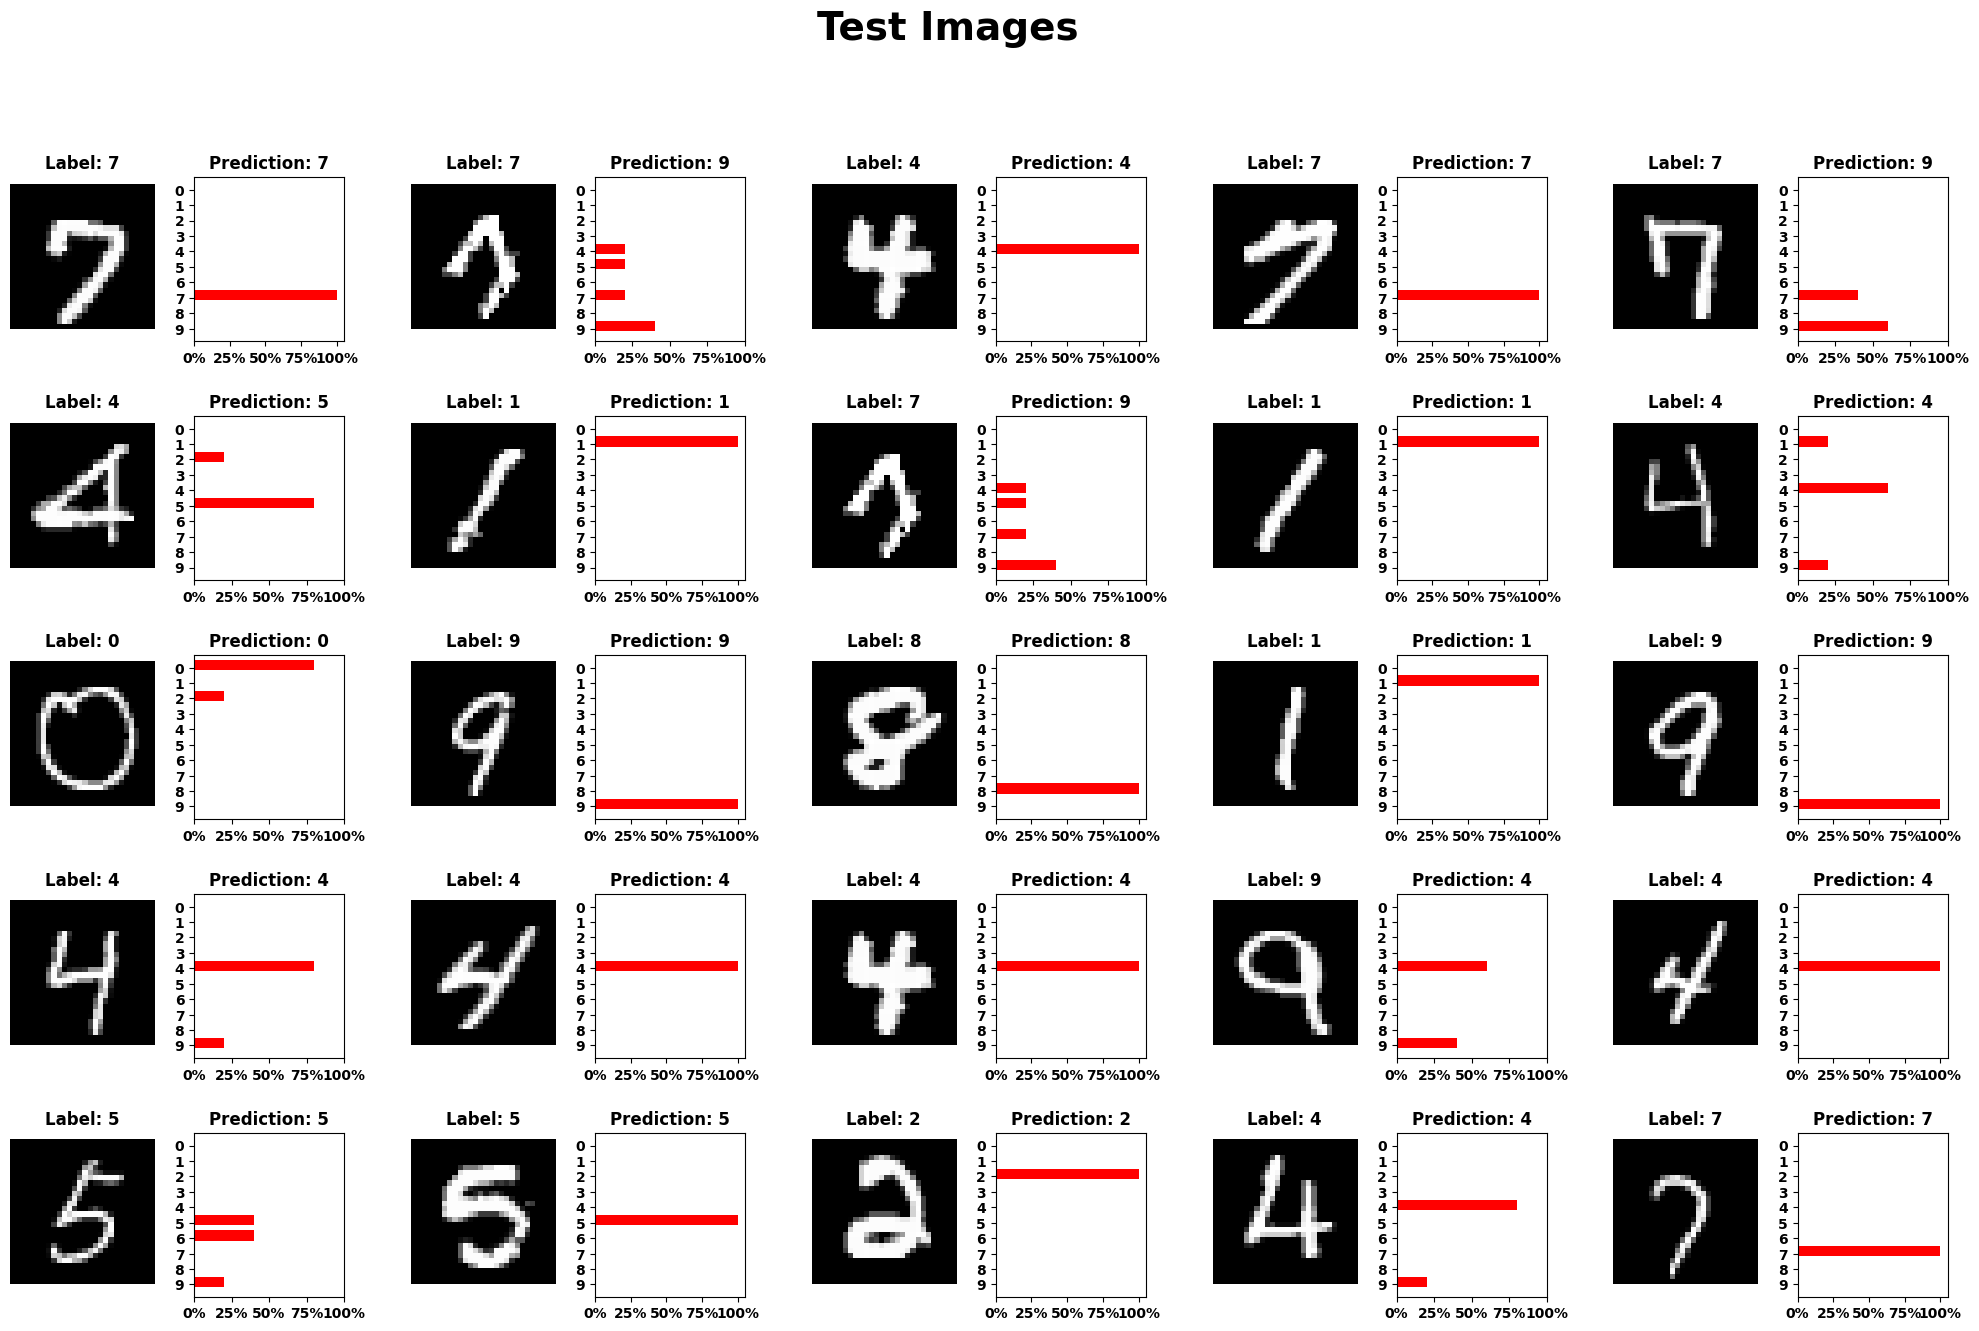

In [131]:
# Change k value to 5
knn = KNNModel(x_train, y_train, k=5)
# Predictions
pred_valid = knn.predict(x_valid, dist_l2)
pred_test, pred_freq_test = knn.predict(x_test, dist_l2, get_freq=True)
# Evaluation
acc_valid = get_accuracy(y_valid, pred_valid)
acc_test = get_accuracy(y_test, pred_test)
print(f'Validation accuracy: {100 * acc_valid:.2f}%')
print(f'Test accuracy: {100 * acc_test:.2f}%')

# Show test results
axs = plot_predictions(x_test, y_test, pred_freq_test, show_max=25, seed=None)

## Motivating Random Forests: Decision Trees

Random forests are an example of an *ensemble learner* built on decision trees.
For this reason we'll start by discussing decision trees themselves.

Decision trees are extremely intuitive ways to classify or label objects: you simply ask a series of questions designed to zero-in on the classification.
For example, if you wanted to build a decision tree to classify an animal you come across while on a hike, you might construct the one shown here:

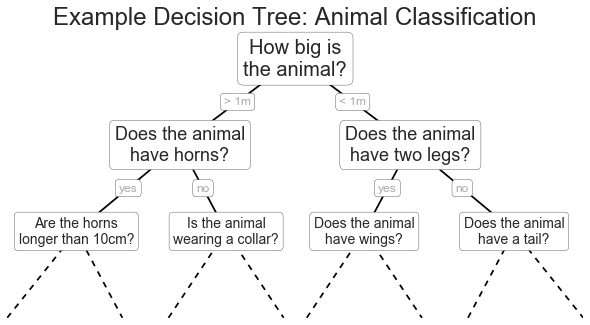

The binary splitting makes this extremely efficient: in a well-constructed tree, each question will cut the number of options by approximately half, very quickly narrowing the options even among a large number of classes.
The trick, of course, comes in deciding which questions to ask at each step.
In machine learning implementations of decision trees, the questions generally take the form of axis-aligned splits in the data: that is, each node in the tree splits the data into two groups using a cutoff value within one of the features.


Entropy Information Gain

Decision Trees can exploit two different functions to measure the impurity of a node: Entropy Information Gain that is reported below as a remainder:
$$Entropy = \sum_{i=1}^{n}-p(c_i)log_2(p(c_i))$$

# Scikit-learn implementation of decision trees
Scikit-learn allows you to create decision trees in a simple and intuitive way. In particular, it allows to use both Gini and Entropy as impurity measurements, and to select two different splitting modes: best and random.
- Using best, the model takes the feature with the highest importance
- Using random, the model takes the feature randomly but with the same distribution.

# EX6

Complete the code below.

In [90]:
from sklearn.tree import DecisionTreeClassifier

#### HERE YOUR PARAMETERS ####
criterion = "gini" # This controls how the tree decides the “best split” at each node: gini can be slightly faster and is most commonly used
splitter  = "best" # Chooses the best possible split (more accurate, but slower)
tree = DecisionTreeClassifier(criterion=criterion, splitter=splitter, random_state=1)
tree.fit(x_train, y_train)
print('Accuracy score: {}'.format(tree.score(x_valid, y_valid)))

Accuracy score: 0.746875


In [91]:
#Test here your best model on the test set
print('Accuracy score: {}'.format(tree.score(x_test, y_test)))

Accuracy score: 0.68


In [92]:
# Train and validation accuracy vs depth of the tree
train_acc = []
val_acc = []
for i in range(1,100):
  tree_depth = DecisionTreeClassifier(criterion=criterion, splitter=splitter, random_state=1, max_depth=i)
  tree_depth.fit(x_train, y_train)
  train_acc.append(tree_depth.score(x_train, y_train))
  val_acc.append(tree_depth.score(x_valid, y_valid))

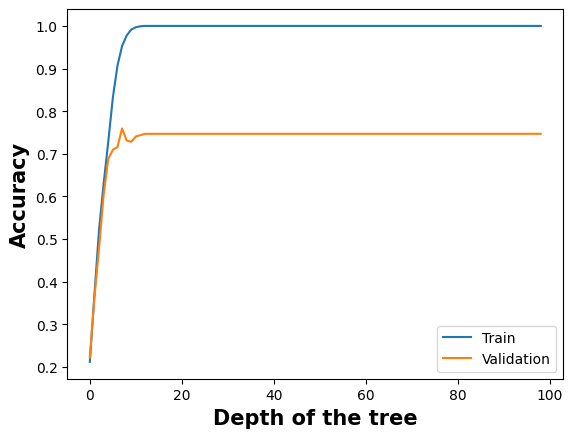

In [93]:
# Plot train and validation accuracy vs depth of the tree
plt.plot(train_acc, label='Train')
plt.plot(val_acc, label='Validation')
plt.legend()
plt.xlabel('Depth of the tree', fontweight='bold', fontsize=15)
plt.ylabel('Accuracy', fontweight='bold', fontsize=15)
plt.show()

In [94]:
# Train and validation accuracy vs max leaf nodes in the tree
train_acc = []
val_acc = []
for i in range(2,100):
  tree_leaf = DecisionTreeClassifier(criterion=criterion, splitter=splitter, random_state=1, max_leaf_nodes=i)
  tree_leaf.fit(x_train, y_train)
  train_acc.append(tree_leaf.score(x_train, y_train))
  val_acc.append(tree_leaf.score(x_valid, y_valid))

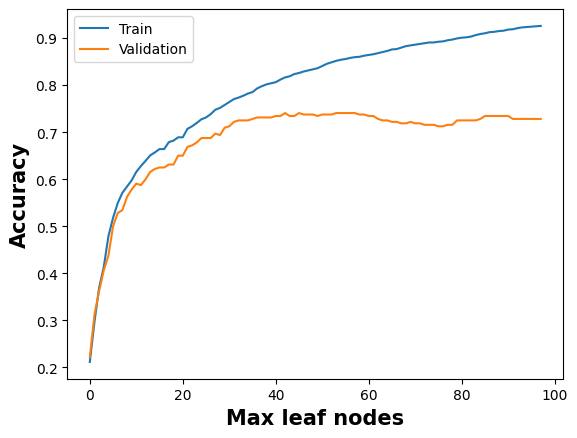

In [95]:
# Plot train and validation accuracy vs max leaf nodes of the tree
plt.plot(train_acc, label='Train')
plt.plot(val_acc, label='Validation')
plt.legend()
plt.xlabel('Max leaf nodes', fontweight='bold', fontsize=15)
plt.ylabel('Accuracy', fontweight='bold', fontsize=15)
plt.show()

### Decision trees and over-fitting

Over-fitting is a general property of decision trees: it is very easy to go too deep in the tree, and thus to fit details of the particular data rather than the overall properties of the distributions they are drawn from.


In [96]:
print('Accuracy score on training set: {}'.format(tree.score(x_train, y_train)))

Accuracy score on training set: 1.0


## Ensembles of Estimators: Random Forests

This notion—that multiple overfitting estimators can be combined to reduce the effect of this overfitting—is what underlies an ensemble method called *bagging*.
Bagging makes use of an ensemble (a grab bag, perhaps) of parallel estimators, each of which over-fits the data, and averages the results to find a better classification.
An ensemble of randomized decision trees is known as a *random forest*.

## Scikit-learn Random forest

# EX 7

Complete the code below.

In [98]:
from sklearn.ensemble import RandomForestClassifier
#### HERE YOUR PARAMETERS ####
criterion = "entropy"
n_estimators = 100
random_forest = RandomForestClassifier(n_estimators=n_estimators, random_state=1, criterion=criterion)
random_forest.fit(x_train, y_train)
print('Accuracy score: {}'.format(random_forest.score(x_valid, y_valid)))


Accuracy score: 0.9


In [99]:
#Test here your best model on the test set
print('Accuracy score: {}'.format(random_forest.score(x_test, y_test)))

Accuracy score: 0.8875
